# Competencia de modelos predictivos

## Contexto

Una startup de educación vende cursos de programación e IA a alumnos universitarios. Tienen un problema clásico: muchos alumnos se inscriben pero después se dan de baja o no completan sus pagos. El área comercial quiere anticipar quiénes van a abandonar para activar acciones de retención antes de que sea tarde.

Su tarea es entrenar un modelo predictivo para anticipar la variable `target_baja`:

- `1` = el alumno se da de baja o no completa sus pagos
- `0` = el alumno continúa o completa sus pagos

## Reglas de la competencia

- Cada grupo tiene asignado un modelo específico (comunicado por el docente).
- **No hay entrega de CSV.** Cada grupo presenta en clase: qué métrica eligieron, cuánto les dio, y por qué.

## Archivos disponibles

- `dataset_alumnos_train_v2.csv` — datos con `target_baja`. Para entrenar y validar.
- `dataset_alumnos_holdout_sin_target_v2.csv` — datos sin `target_baja`. Opcional: úsenlo para hacer EDA cruzado o generar predicciones de muestra.

## Qué tienen que llevar a la presentación

1. La métrica que eligieron y **por qué esa y no otra**.
2. El valor que obtuvieron en su validación interna.
3. Tres decisiones técnicas que tomaron (qué features usaron/descartaron, cómo trataron nulos, cómo splitearon, etc.) y por qué.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("dataset_alumnos_train_v2.csv")
holdout = pd.read_csv("dataset_alumnos_holdout_sin_target_v2.csv")

print("Train:", train.shape)
print("Holdout:", holdout.shape)
train.head()

Train: (1428, 39)
Holdout: (800, 38)


,student_id,cohort_month,course,channel,university,career_area,city,age,work_status,prior_programming_experience,...,newsletter_clicks_last_30d,preferred_class_day,device_type,browser,avatar_color,zodiac_sign,internal_random_code,last_digit_phone,flag_gestion_retencion,target_baja
0,TRAIN_00001,2025-02,IA Generativa,Google Ads,UADE,Economia,La Plata,21,Freelance,Avanzada,...,2,Jueves,Desktop,Chrome,Verde,Geminis,X5830,6,0,0
1,TRAIN_00002,2024-08,Python,Google Ads,Universidad Austral,Psicologia,CABA,21,Full-time,Ninguna,...,1,Lunes,Desktop,Chrome,Naranja,Geminis,X3783,0,0,1
2,TRAIN_00003,2025-04,Python,Evento,UBA,Cs Datos,GBA Norte,22,No trabaja,Basica,...,3,Jueves,Mobile,Safari,Azul,Geminis,X2157,9,0,0
3,TRAIN_00004,2025-02,IA Generativa,Instagram Ads,UBA,Administracion,CABA,26,Freelance,Basica,...,4,Martes,Desktop,Chrome,Azul,Virgo,X4102,7,0,0
4,TRAIN_00005,2025-03,Web Dev,Google Ads,UADE,Administracion,Cordoba,18,Full-time,Basica,...,0,Martes,Mobile,Edge,Azul,Leo,X2452,4,0,0


## 2. EDA exploratorio

Las celdas que siguen muestran los datos. **No sacan conclusiones, ni les dicen qué hacer con lo que ven.** Eso es trabajo de ustedes.

Léanlas con atención. Cada output esconde por lo menos una pista sobre algo que vale la pena mirar antes de modelar.

### 2.1 Distribución de la variable a predecir

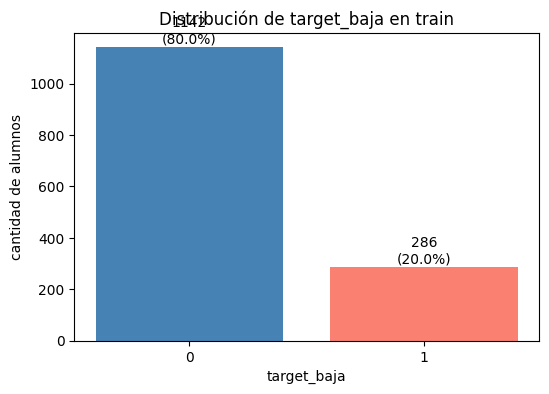

In [2]:
target_counts = train["target_baja"].value_counts().sort_index()
target_pct = train["target_baja"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index.astype(str), target_counts.values, color=["steelblue", "salmon"])
for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, count + 15, f"{count}\n({pct:.1%})", ha="center")
ax.set_xlabel("target_baja")
ax.set_ylabel("cantidad de alumnos")
ax.set_title("Distribución de target_baja en train")
plt.show()

### 2.2 Tipos y nulos por columna

In [3]:
resumen = pd.DataFrame({
    "tipo": train.dtypes.astype(str),
    "nulos": train.isna().sum(),
    "pct_nulos": (train.isna().mean() * 100).round(1),
    "valores_unicos": train.nunique()
})
resumen.sort_values("pct_nulos", ascending=False)

,tipo,nulos,pct_nulos,valores_unicos
satisfaction_first_week,float64,414,29.0,65
prior_programming_experience,str,100,7.0,4
hours_available_week,float64,81,5.7,165
lead_score_marketing,str,52,3.6,3
payment_method,str,46,3.2,5
response_time_sales_hours,float64,39,2.7,389
university,str,30,2.1,7
city,str,0,0.0,9
career_area,str,0,0.0,7
channel,str,0,0.0,7


### 2.3 Estadísticos de variables numéricas

In [4]:
train.select_dtypes(include=["int64", "float64"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1428.0,23.87,4.44,17.0,21.0,24.0,27.0,55.0
hours_available_week,1347.0,7.26,3.55,0.0,4.8,7.3,9.7,19.0
installments_plan,1428.0,4.49,2.85,1.0,3.0,3.0,6.0,12.0
course_price_final,1428.0,205942.58,48489.92,68000.0,176000.0,201500.0,233000.0,538000.0
discount_pct,1428.0,16.95,11.17,0.0,10.0,15.0,25.0,45.0
days_between_signup_and_start,1428.0,13.75,8.50,0.0,7.0,13.0,20.0,41.0
response_time_sales_hours,1389.0,14.24,20.93,0.1,3.7,8.8,17.5,396.0
opened_welcome_email,1428.0,0.76,0.43,0.0,1.0,1.0,1.0,1.0
attended_intro_webinar,1428.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0
first_class_attendance,1428.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0


### 2.4 Variables categóricas: cardinalidad y top valores

In [5]:
def top_3_str(serie):
    top = serie.value_counts().head(3)
    return ", ".join(f"{k} ({v})" for k, v in top.items())

categoricas = train.select_dtypes(exclude=["number"]).columns
resumen_cat = pd.DataFrame({
    "valores_unicos": [train[c].nunique() for c in categoricas],
    "top_3": [top_3_str(train[c]) for c in categoricas]
}, index=categoricas)
resumen_cat

,valores_unicos,top_3
student_id,1428,"TRAIN_00001 (1), TRAIN_00002 (1), TRAIN_00003 (1)"
cohort_month,8,"2025-04 (202), 2024-10 (195), 2025-02 (187)"
course,6,"Python (366), Data Analytics (305), Web Dev (235)"
channel,7,"Instagram Ads (357), TikTok Ads (290), Referid..."
university,7,"UTN (279), UBA (275), Otra (252)"
career_area,7,"Ingenieria (341), Cs Datos (228), Otra (225)"
city,9,"CABA (441), GBA Norte (177), GBA Sur (146)"
work_status,5,"No trabaja (386), Full-time (337), Part-time (..."
prior_programming_experience,4,"Ninguna (485), Basica (458), Intermedia (283)"
payment_method,5,"Tarjeta credito (447), Transferencia (326), Me..."


### 2.5 Histogramas de variables numéricas seleccionadas

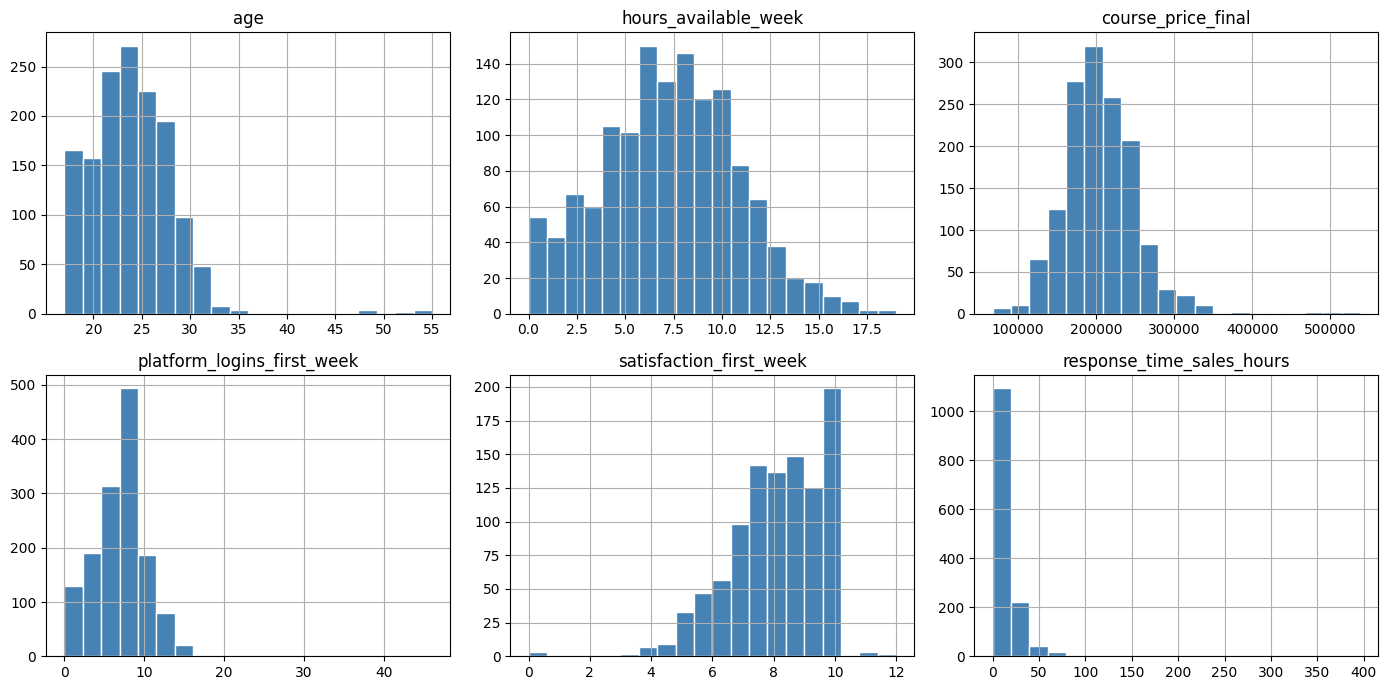

In [6]:
numericas_a_plotear = [
    "age", "hours_available_week", "course_price_final",
    "platform_logins_first_week", "satisfaction_first_week", "response_time_sales_hours"
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), numericas_a_plotear):
    train[col].hist(ax=ax, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.6 Comparación train vs holdout

Mismas columnas (excepto `target_baja`). ¿Se distribuyen igual?

In [7]:
# Tasa de nulos en cada dataset, columna por columna
nulos_train = train.drop(columns=["target_baja"]).isna().mean()
nulos_holdout = holdout.isna().mean()

comparacion_nulos = pd.DataFrame({
    "pct_nulos_train": (nulos_train * 100).round(1),
    "pct_nulos_holdout": (nulos_holdout * 100).round(1)
})
comparacion_nulos["diferencia_pp"] = (comparacion_nulos["pct_nulos_train"] - comparacion_nulos["pct_nulos_holdout"]).round(1)
comparacion_nulos.sort_values("diferencia_pp", key=abs, ascending=False).head(10)

,pct_nulos_train,pct_nulos_holdout,diferencia_pp
satisfaction_first_week,29.0,17.5,11.5
prior_programming_experience,7.0,9.8,-2.8
lead_score_marketing,3.6,4.8,-1.2
university,2.1,2.6,-0.5
payment_method,3.2,2.8,0.4
hours_available_week,5.7,6.1,-0.4
response_time_sales_hours,2.7,2.6,0.1
career_area,0.0,0.0,0.0
course,0.0,0.0,0.0
cohort_month,0.0,0.0,0.0


In [8]:
# Promedio de variables numéricas en train vs holdout
numericas_comunes = train.drop(columns=["target_baja"]).select_dtypes(include=["int64", "float64"]).columns
comparacion_medias = pd.DataFrame({
    "media_train": train[numericas_comunes].mean().round(3),
    "media_holdout": holdout[numericas_comunes].mean().round(3)
})
comparacion_medias["dif_relativa_pct"] = (
    (comparacion_medias["media_train"] - comparacion_medias["media_holdout"])
    / comparacion_medias["media_train"].replace(0, np.nan) * 100
).round(1)
comparacion_medias.sort_values("dif_relativa_pct", key=abs, ascending=False).head(10)

,media_train,media_holdout,dif_relativa_pct
flag_gestion_retencion,0.175,0.024,86.3
response_time_sales_hours,14.236,17.031,-19.6
scholarship_requested,0.146,0.174,-19.2
payment_failed_first_attempt,0.231,0.265,-14.7
first_class_attendance,0.646,0.556,13.9
platform_logins_first_week,7.177,6.300,12.2
questions_to_tutor_week1,2.276,1.999,12.2
assignments_submitted_week1,3.110,2.841,8.6
attended_intro_webinar,0.363,0.334,8.0
days_between_signup_and_start,13.746,12.726,7.4


## 3. Su trabajo
Lo que esperamos al final es:

- Un modelo entrenado.
- Un número (la métrica que eligieron, calculada sobre su validación interna).
- Tres frases sobre las decisiones que tomaron en el camino.

## 4. Para la presentación en clase

Antes de presentar, completen este checklist mental:

- **Métrica elegida:** ¿cuál? ¿Por qué esa y no otra?
- **Valor obtenido:** ¿cuánto les dio?
- **¿Sería el mismo número en otro split?** ¿Hicieron cross-validation o probaron con varias semillas?
- **Tres decisiones técnicas clave:** features que descartaron, tratamiento de nulos, hiperparámetros que cambiaron.
- **Una cosa que les llamó la atención en el EDA** y cómo la incorporaron (o no) al modelo.